

# **Question 3**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
df = pd.read_csv('hepatitis_B2.csv')

In [4]:
df.shape

(40, 20)

In [5]:
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN,HISTOLOGY,Age_Quartile
0,1,39,1,1,1,1,1,2,2,1,2,2,2,2,2.3,280,98,3.8,1,Q2
1,1,37,1,2,2,1,2,2,2,2,2,1,2,2,0.6,67,28,4.2,1,Q2
2,1,58,1,2,2,1,2,2,1,1,1,1,2,2,2.0,167,242,3.3,1,Q4
3,1,30,1,2,2,1,1,1,2,1,2,1,1,1,2.5,165,64,2.8,2,Q1
4,1,38,1,1,2,1,1,1,2,1,2,1,1,1,1.2,118,16,2.8,2,Q2


In [6]:
df.isnull().sum()

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER_BIG          0
LIVER_FIRM         0
SPLEEN_PALPABLE    0
SPIDERS            0
ASCITES            0
 VARICES           0
BILIRUBIN          0
ALK_PHOSPHATE      0
SGOT               0
ALBUMIN            0
HISTOLOGY          0
Age_Quartile       0
dtype: int64

In [7]:
df_clean = df.dropna()

In [8]:
# Select only the relevant features as specified in the problem
features = ['AGE', 'SEX', 'ASCITES', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN']
X = df_clean[features]
y = df_clean['Class']

In [9]:
# Display descriptive statistics for selected features
X.describe()

,AGE,SEX,ASCITES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN
count,40.00000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,42.35000,1.100000,1.750000,1.490000,101.97500,71.825000,3.645000
std,11.86797,0.303822,0.438529,1.091647,51.05125,59.340775,0.651212
min,22.00000,1.000000,1.000000,0.400000,45.00000,16.000000,2.100000
25%,33.75000,1.000000,1.750000,0.775000,66.50000,28.000000,3.250000
50%,40.50000,1.000000,2.000000,1.100000,85.00000,54.000000,3.800000
75%,49.00000,1.000000,2.000000,2.000000,119.25000,91.250000,4.100000
max,78.00000,2.000000,2.000000,4.800000,280.00000,249.000000,4.900000


In [10]:
# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [11]:
X_scaled_df.head()

,AGE,SEX,ASCITES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN
0,-0.285868,-0.333333,0.577350,0.751451,3.531606,0.446716,0.241050
1,-0.456536,-0.333333,0.577350,-0.825668,-0.693824,-0.747939,0.863114
2,1.335474,-0.333333,0.577350,0.473136,1.289946,2.904292,-0.536531
3,-1.053873,-0.333333,-1.732051,0.936994,1.250271,-0.133545,-1.314111
4,-0.371202,-0.333333,-1.732051,-0.269038,0.317899,-0.952737,-1.314111


## **Hierarchical Clustering**

In [12]:
# Calculate the linkage matrix using Ward method
Z = linkage(X_scaled, method='ward', metric='euclidean')

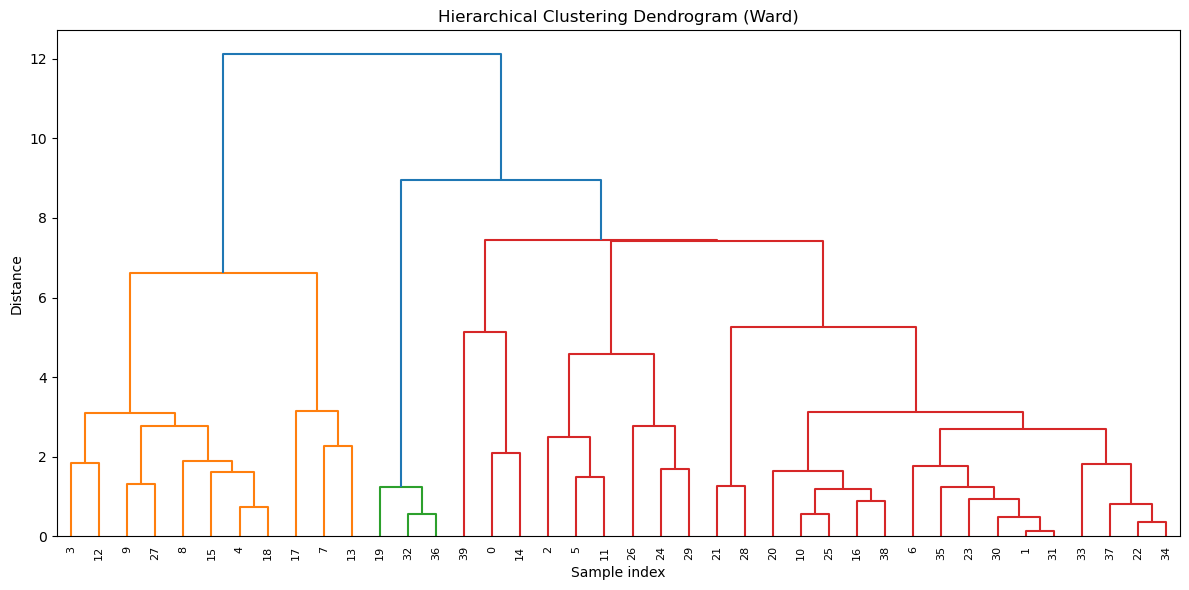

In [13]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.tight_layout()

In [14]:
# Perform hierarchical clustering with 2 clusters
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward', metric='euclidean')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

In [15]:
# Add hierarchical cluster labels to the dataframe
df_clean['Hierarchical_Cluster'] = hierarchical_labels

In [16]:
# Create a cross-tabulation of actual class vs. hierarchical clusters
hierarchical_cross_tab = pd.crosstab(
    df_clean['Class'], 
    df_clean['Hierarchical_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['Hierarchical Cluster']
)

In [17]:
hierarchical_cross_tab

Hierarchical Cluster,0,1
Actual Class,,
1,9,10
2,20,1


In [18]:
# Calculate percentage distribution of each class within clusters
hierarchical_cross_tab_percent = pd.crosstab(
    df_clean['Class'], 
    df_clean['Hierarchical_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['Hierarchical Cluster'],
    normalize='columns'
) * 100

In [19]:
# Percentage Distribution within Hierarchical Clusters
hierarchical_cross_tab_percent

Hierarchical Cluster,0,1
Actual Class,,
1,31.034483,90.909091
2,68.965517,9.090909


In [20]:
# Calculate Adjusted Rand Index (ARI) for hierarchical clustering
hierarchical_ari = adjusted_rand_score(y, hierarchical_labels)

In [21]:
hierarchical_ari

0.23398739025396265

In [22]:
# Calculate silhouette score for hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

In [23]:
hierarchical_silhouette

0.2904975290969881

## **K-means Clustering**

In [24]:
# Perform K-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [25]:
# Add K-means cluster labels to the dataframe
df_clean['KMeans_Cluster'] = kmeans_labels

In [26]:
# Create a cross-tabulation of actual class vs. K-means clusters
kmeans_cross_tab = pd.crosstab(
    df_clean['Class'], 
    df_clean['KMeans_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['K-means Cluster']
)

In [27]:
kmeans_cross_tab

K-means Cluster,0,1
Actual Class,,
1,10,9
2,20,1


In [28]:
# Calculate percentage distribution of each class within clusters
kmeans_cross_tab_percent = pd.crosstab(
    df_clean['Class'], 
    df_clean['KMeans_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['K-means Cluster'],
    normalize='columns'
) * 100

In [29]:
# Percentage Distribution within K-means Clusters
kmeans_cross_tab_percent

K-means Cluster,0,1
Actual Class,,
1,33.333333,90.0
2,66.666667,10.0


In [30]:
# Calculate Adjusted Rand Index (ARI) for K-means clustering
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

In [31]:
kmeans_ari

0.1863841475377673

In [32]:
# Calculate silhouette score for K-means clustering
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

In [33]:
kmeans_silhouette

0.2967641975888987

In [34]:
# Compute PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [35]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Class': y,
    'Hierarchical': hierarchical_labels,
    'KMeans': kmeans_labels
})

## **Visualize Clusters with PCA**

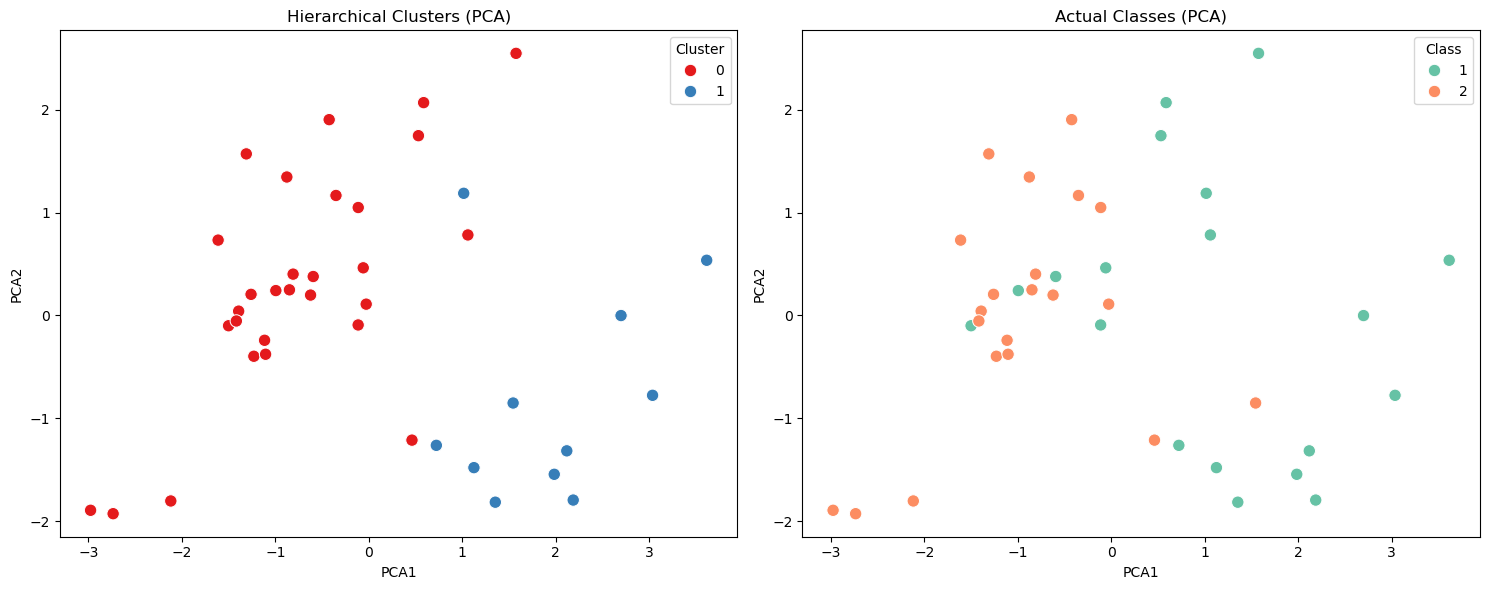

In [36]:
# Plot PCA visualization for Hierarchical Clustering
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='Hierarchical', data=pca_df, palette='Set1', s=80)
plt.title('Hierarchical Clusters (PCA)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PCA1', y='PCA2', hue='Class', data=pca_df, palette='Set2', s=80)
plt.title('Actual Classes (PCA)')
plt.legend(title='Class')

plt.tight_layout()

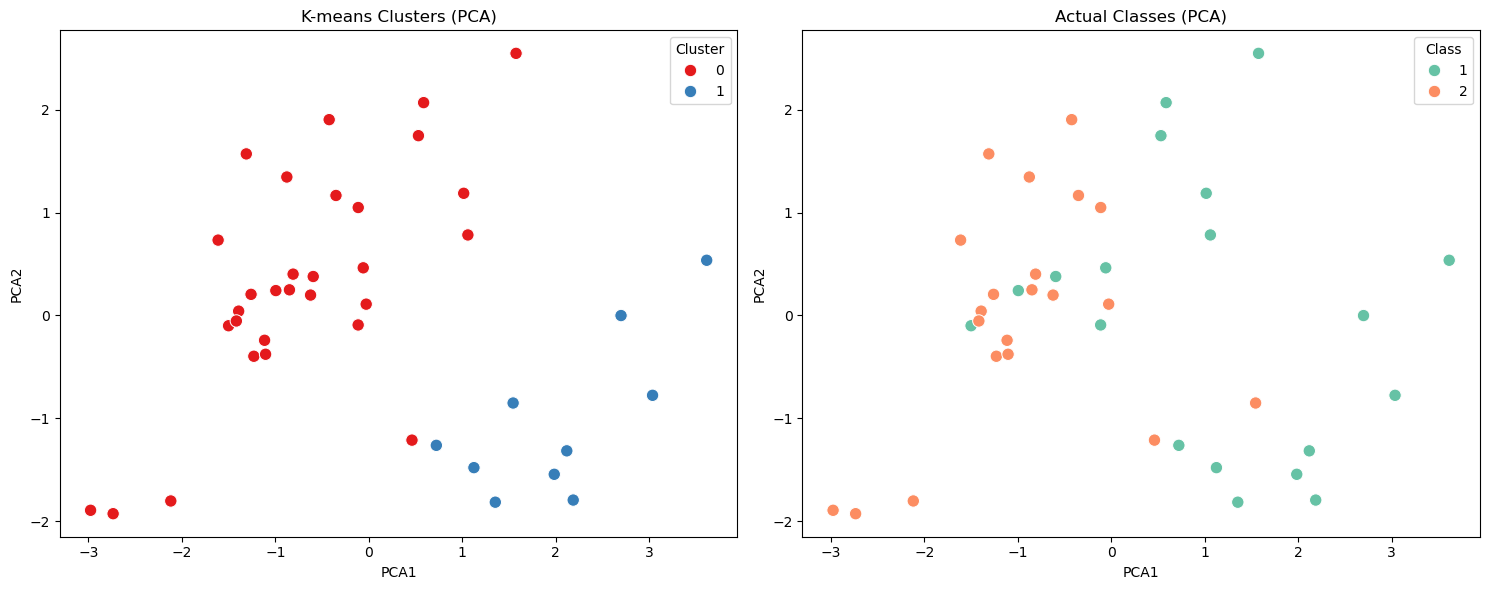

In [37]:
# Plot PCA visualization for K-means Clustering
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans', data=pca_df, palette='Set1', s=80)
plt.title('K-means Clusters (PCA)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PCA1', y='PCA2', hue='Class', data=pca_df, palette='Set2', s=80)
plt.title('Actual Classes (PCA)')
plt.legend(title='Class')

plt.tight_layout()

## **Feature Analysis by Cluster**

In [38]:
# Calculate cluster centers for K-means
kmeans_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
kmeans_centers.index = ['Cluster 0', 'Cluster 1']

In [39]:
kmeans_centers

,AGE,SEX,ASCITES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN
Cluster 0,42.1,1.133333,2.0,1.236667,98.3,75.6,3.936667
Cluster 1,43.1,1.000000,1.0,2.250000,113.0,60.5,2.770000


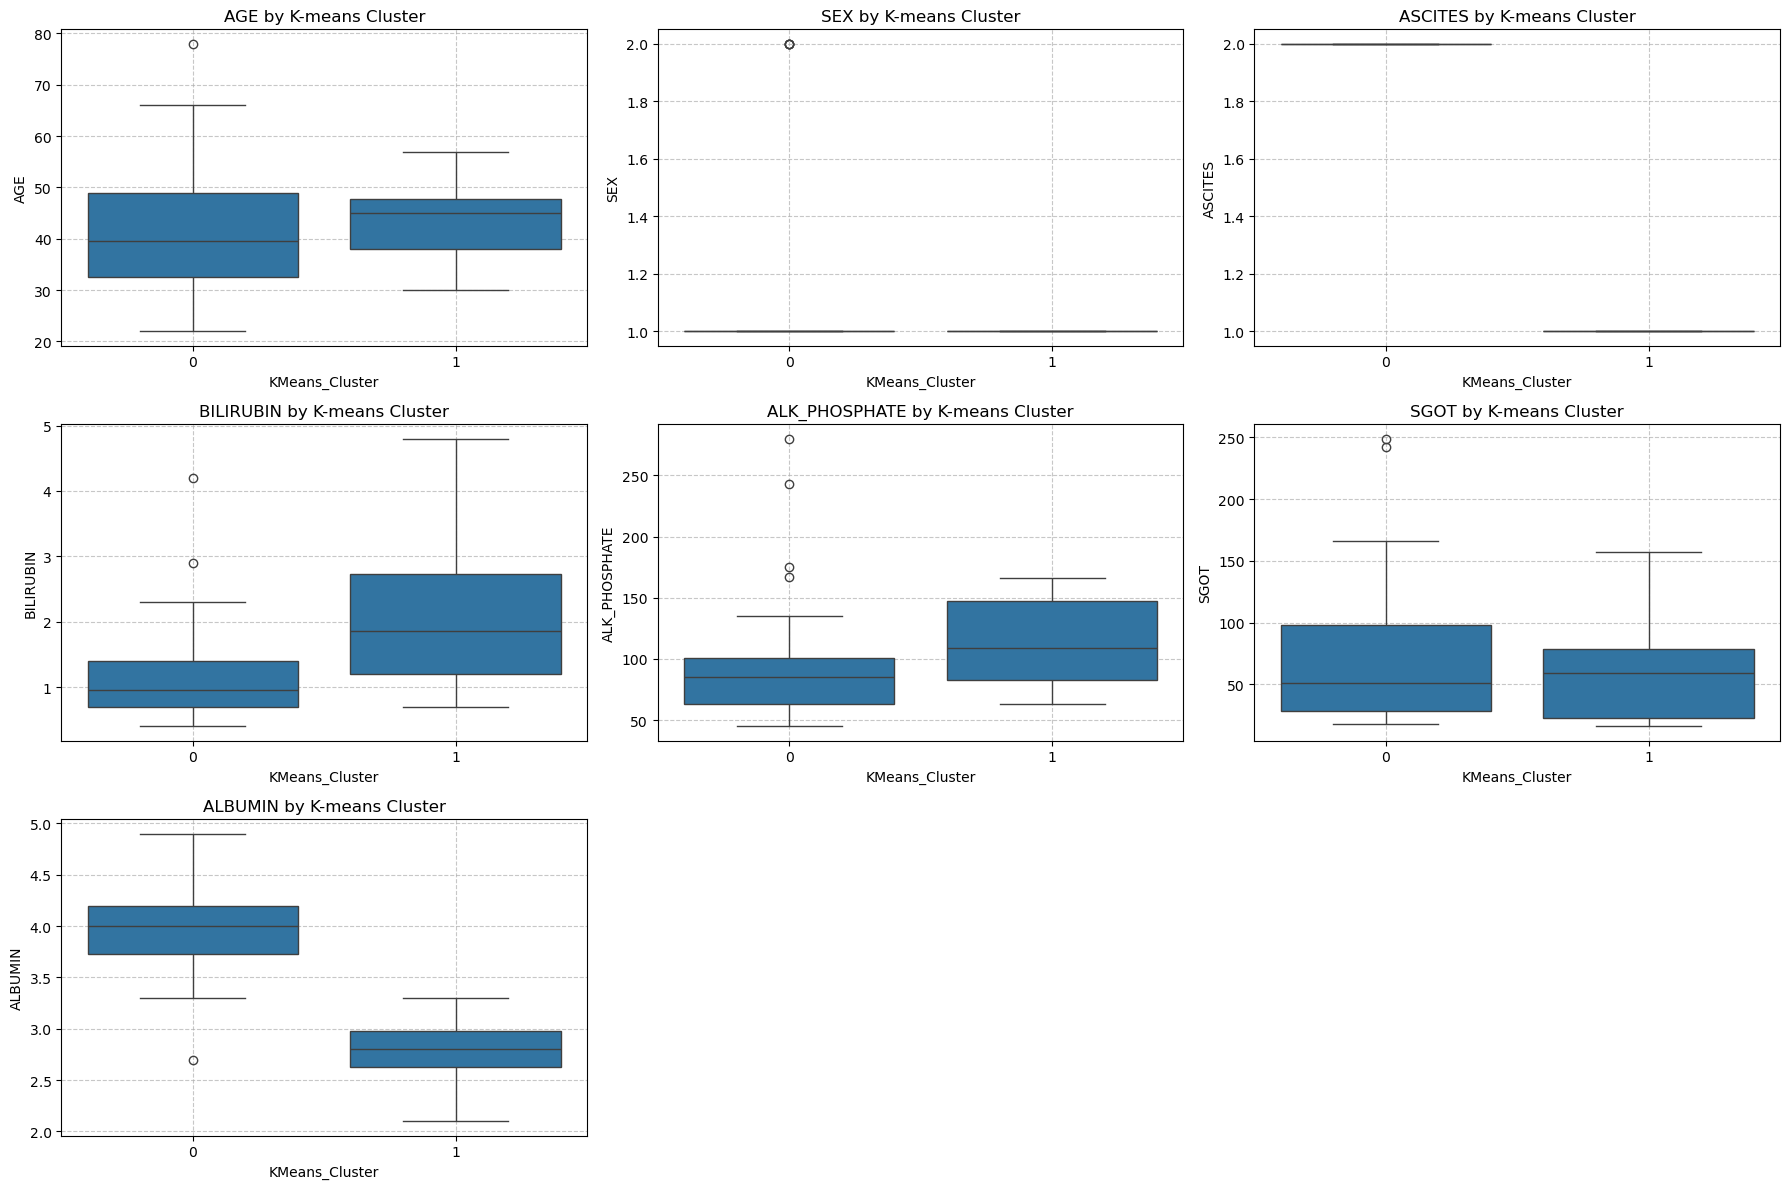

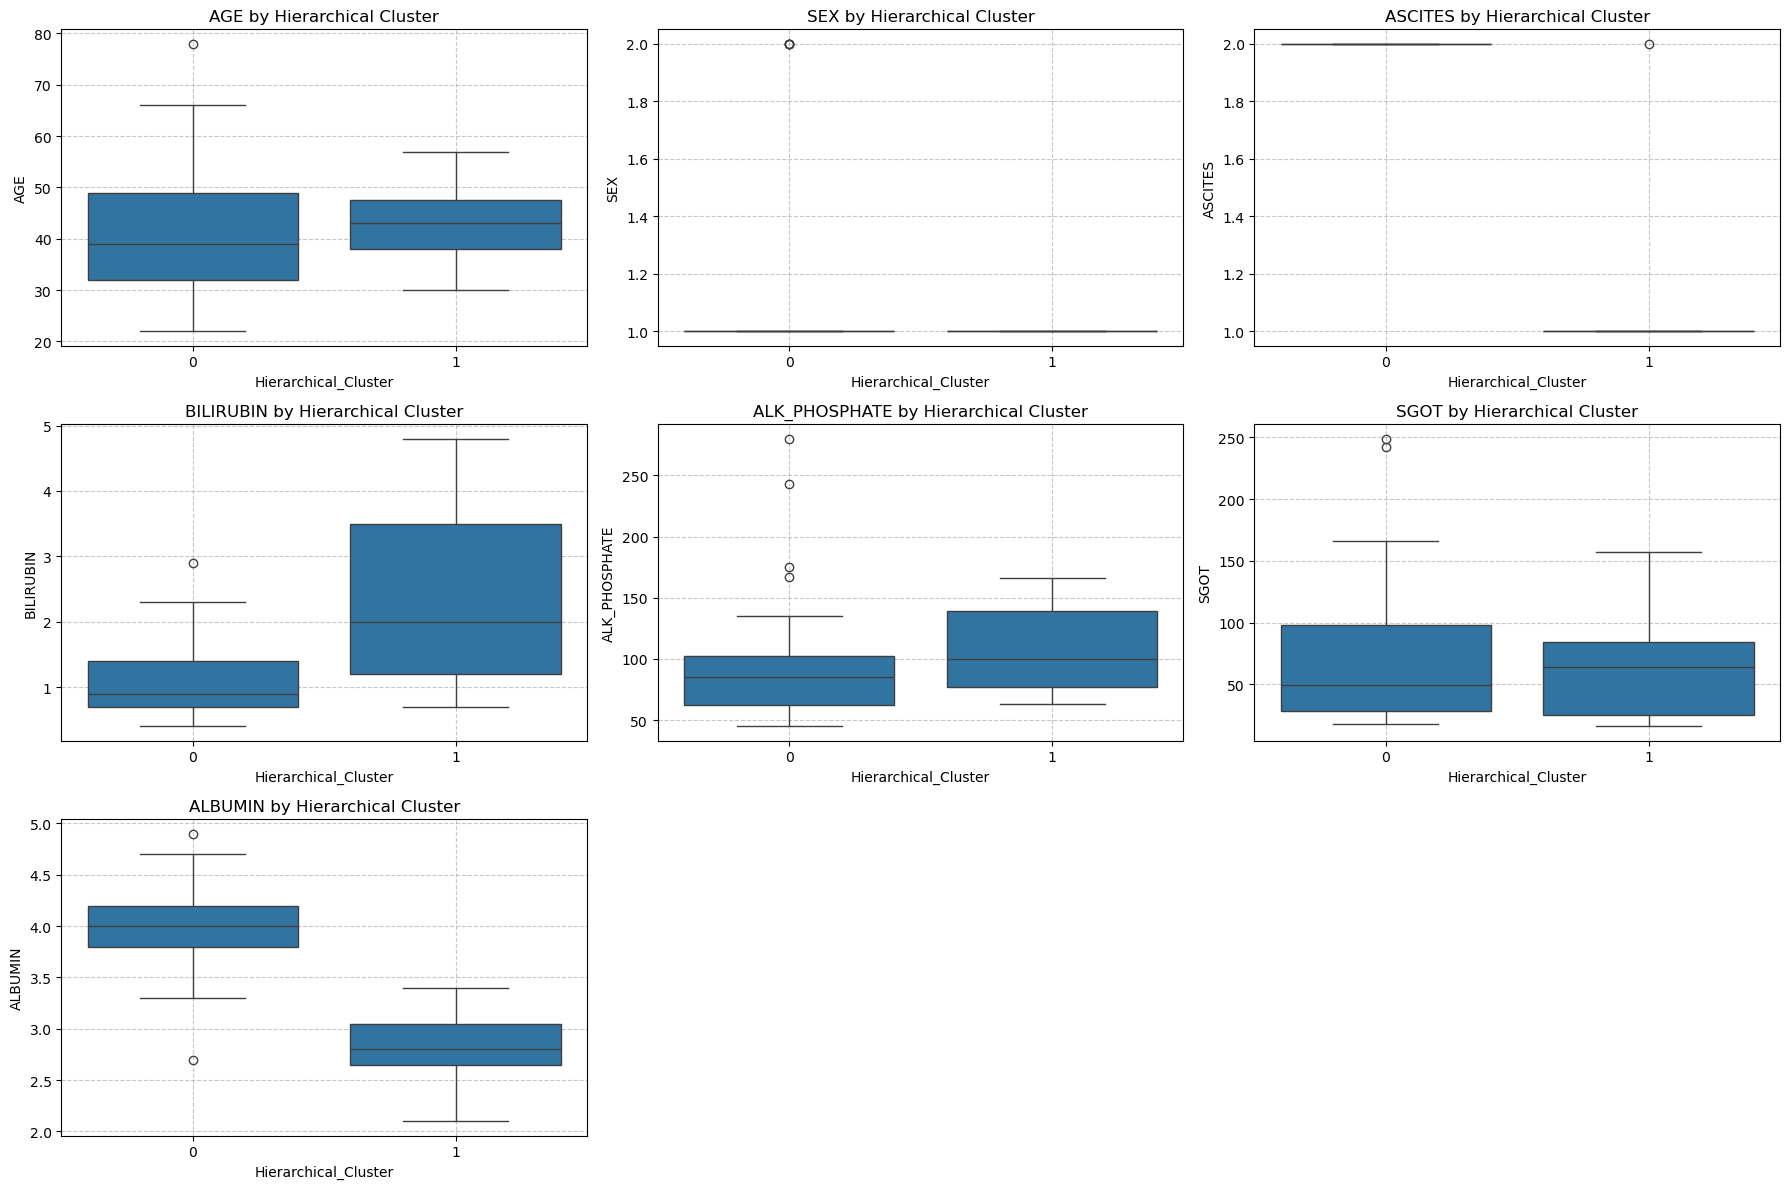

In [40]:
# Create plots to compare feature distributions by cluster
plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='KMeans_Cluster', y=feature, data=df_clean)
    plt.title(f'{feature} by K-means Cluster')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Hierarchical_Cluster', y=feature, data=df_clean)
    plt.title(f'{feature} by Hierarchical Cluster')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

In [41]:
comparison_df = pd.DataFrame({
    'Algorithm': ['Hierarchical', 'K-means'],
    'Adjusted Rand Index': [hierarchical_ari, kmeans_ari],
    'Silhouette Score': [hierarchical_silhouette, kmeans_silhouette]
})
print(comparison_df)

# Calculate agreement between the two clustering methods
clustering_agreement = adjusted_rand_score(hierarchical_labels, kmeans_labels)
print(f"Agreement between Hierarchical and K-means (ARI): {clustering_agreement:.4f}")


      Algorithm  Adjusted Rand Index  Silhouette Score
0  Hierarchical             0.233987          0.290498
1       K-means             0.186384          0.296764
Agreement between Hierarchical and K-means (ARI): 0.8956


In [42]:
# Cross-tabulation of hierarchical vs K-means clusters
alg_comparison = pd.crosstab(
    df_clean['Hierarchical_Cluster'], 
    df_clean['KMeans_Cluster'], 
    rownames=['Hierarchical'], 
    colnames=['K-means']
)
print("Cross-tabulation of Hierarchical vs. K-means Clusters:")
print(alg_comparison)


Cross-tabulation of Hierarchical vs. K-means Clusters:
K-means        0   1
Hierarchical        
0             29   0
1              1  10


In [43]:
# For Hierarchical Clustering
for cluster in [0, 1]:
    cluster_data = df_clean[df_clean['Hierarchical_Cluster'] == cluster]
    class_dist = cluster_data['Class'].value_counts(normalize=True) * 100
    print(f"Hierarchical Cluster {cluster}:")
    print(f"Size: {len(cluster_data)} samples ({len(cluster_data)/len(df_clean)*100:.1f}% of data)")
    print(f"Class distribution: Class 1 (Died): {class_dist.get(1, 0):.1f}%, Class 2 (Survived): {class_dist.get(2, 0):.1f}%")
    print("Average feature values:")
    print(cluster_data[features].mean())


Hierarchical Cluster 0:
Size: 29 samples (72.5% of data)
Class distribution: Class 1 (Died): 31.0%, Class 2 (Survived): 69.0%
Average feature values:
AGE              42.137931
SEX               1.137931
ASCITES           2.000000
BILIRUBIN         1.134483
ALK_PHOSPHATE    99.448276
SGOT             74.068966
ALBUMIN           3.955172
dtype: float64
Hierarchical Cluster 1:
Size: 11 samples (27.5% of data)
Class distribution: Class 1 (Died): 90.9%, Class 2 (Survived): 9.1%
Average feature values:
AGE               42.909091
SEX                1.000000
ASCITES            1.090909
BILIRUBIN          2.427273
ALK_PHOSPHATE    108.636364
SGOT              65.909091
ALBUMIN            2.827273
dtype: float64


In [44]:
# For K-means Clustering
for cluster in [0, 1]:
    cluster_data = df_clean[df_clean['KMeans_Cluster'] == cluster]
    class_dist = cluster_data['Class'].value_counts(normalize=True) * 100
    print(f"K-means Cluster {cluster}:")
    print(f"Size: {len(cluster_data)} samples ({len(cluster_data)/len(df_clean)*100:.1f}% of data)")
    print(f"Class distribution: Class 1 (Died): {class_dist.get(1, 0):.1f}%, Class 2 (Survived): {class_dist.get(2, 0):.1f}%")
    print("Average feature values:")
    print(cluster_data[features].mean())

K-means Cluster 0:
Size: 30 samples (75.0% of data)
Class distribution: Class 1 (Died): 33.3%, Class 2 (Survived): 66.7%
Average feature values:
AGE              42.100000
SEX               1.133333
ASCITES           2.000000
BILIRUBIN         1.236667
ALK_PHOSPHATE    98.300000
SGOT             75.600000
ALBUMIN           3.936667
dtype: float64
K-means Cluster 1:
Size: 10 samples (25.0% of data)
Class distribution: Class 1 (Died): 90.0%, Class 2 (Survived): 10.0%
Average feature values:
AGE               43.10
SEX                1.00
ASCITES            1.00
BILIRUBIN          2.25
ALK_PHOSPHATE    113.00
SGOT              60.50
ALBUMIN            2.77
dtype: float64



### **Key Takeaways**

* The dataset had 40 patients after cleaning, with a nearly even split between those who died and those who survived.

* Both clustering methods produced groupings that did not perfectly match mortality outcomes, indicating limited alignment.

* Hierarchical clustering performed slightly better than K-means in capturing class structure.

* A high agreement between the two methods suggests consistency in how the data was grouped.

* The clusters reflect patterns in the features but do not directly correspond to mortality, suggesting other variables may be important.

* Additional features or domain expertise may help improve clustering relevance to clinical outcomes.
